In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
path = r'H:\3etapa_Py\aula3\Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx'

In [7]:
formacao_bruto = pd.read_excel(path, header=None)

In [8]:
formacao_bruto

,0,1,2,3,4,5,6,7,8,9
0,Tabela 10063 - Pessoas com nível superior comp...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Brasil, Grande Região e Unidade da Federação",Total,NaN,NaN,"Ciência, Tecnologia, Engenharias e Matemática",NaN,NaN,"Educação, Serviços pessoais, Saúde e Bem-estar",NaN,NaN
2,NaN,Total,Homens,Mulheres,Total,Homens,Mulheres,Total,Homens,Mulheres
3,Brasil,25854291,10478534,15375757,4149041,2750422,1398619,8079707,1677985,6401723
4,Norte,1525166,590558,934609,209657,133055,76601,599785,141169,458616
5,Nordeste,4748933,1744994,3003939,621388,389993,231395,1822087,363905,1458181
6,Sudeste,12828829,5391638,7437191,2328122,1588874,739247,3652397,768288,2884108
7,Sul,4338861,1768855,2570005,662916,427372,235543,1256291,248574,1007718
8,Centro-Oeste,2412502,982489,1430013,326959,211124,115834,749148,156048,593101
9,Rondônia,164632,62766,101866,20538,11863,8675,63584,13963,49622


A tabela deverá ser dividida em 3
- homens e mulheres por região com curso superior
- homens e mulheres por região com curso nas áreas de Ciência, Tecnologia, Engenharias e Matemática
- homens e mulheres por região com curso nas áreas de Educação, Serviços pessoais, Saúde e Bem-estar	

Exemplo 1

In [21]:
# : = todas as linhas  |  0:4 = colunas 0, 1, 2 e 3 (as 4 primeiras)
formacao_total = formacao_bruto.iloc[3:36, 0:4].copy()


In [22]:
formacao_total.columns = [
    "uf_regiao",
    "total",
    "total_homens",
    "total_mulheres"
]

In [ ]:
formacao_total

In [28]:
formacao_total["percentual_mulheres"] = ((formacao_total['total_mulheres'] / formacao_total['total']) * 100).round(2)

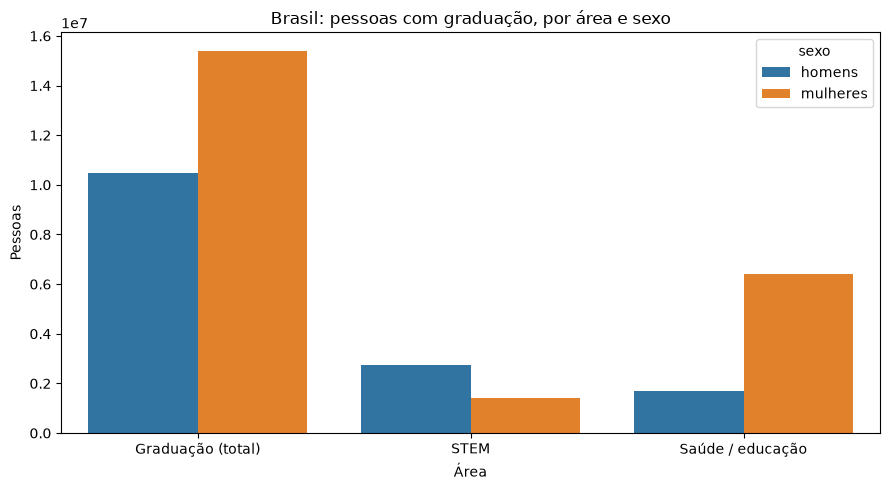

In [14]:

formacao_bruto = pd.read_excel(path, header=None)

formacao_total = formacao_bruto.iloc[3:36, 0:4].copy()
formacao_total.columns = ["uf_regiao", "total", "total_homens", "total_mulheres"]
formacao_total = formacao_total.reset_index(drop=True)
for col in formacao_total.columns[1:]:
    formacao_total[col] = pd.to_numeric(formacao_total[col], errors="coerce")

formacao_stem = formacao_bruto.iloc[3:36, [0, 4, 5, 6]].copy()
formacao_stem.columns = ["uf_regiao", "total", "homens", "mulheres"]
formacao_stem = formacao_stem.reset_index(drop=True)
for col in formacao_stem.columns[1:]:
    formacao_stem[col] = pd.to_numeric(formacao_stem[col], errors="coerce")

formacao_saude = formacao_bruto.iloc[3:36, [0, 7, 8, 9]].copy()
formacao_saude.columns = ["uf_regiao", "total", "homens", "mulheres"]
formacao_saude = formacao_saude.reset_index(drop=True)
for col in formacao_saude.columns[1:]:
    formacao_saude[col] = pd.to_numeric(formacao_saude[col], errors="coerce")


brasil = pd.DataFrame(
    {
        "area": ["Graduação (total)", "STEM", "Saúde / educação"],
        "homens": [
            formacao_total.loc[formacao_total["uf_regiao"] == "Brasil", "total_homens"].item(),
            formacao_stem.loc[formacao_stem["uf_regiao"] == "Brasil", "homens"].item(),
            formacao_saude.loc[formacao_saude["uf_regiao"] == "Brasil", "homens"].item(),
        ],
        "mulheres": [
            formacao_total.loc[formacao_total["uf_regiao"] == "Brasil", "total_mulheres"].item(),
            formacao_stem.loc[formacao_stem["uf_regiao"] == "Brasil", "mulheres"].item(),
            formacao_saude.loc[formacao_saude["uf_regiao"] == "Brasil", "mulheres"].item(),
        ],
    }
)
brasil_long = brasil.melt(id_vars="area", var_name="sexo", value_name="pessoas")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=brasil_long, x="area", y="pessoas", hue="sexo", ax=ax)
ax.set_title("Brasil: pessoas com graduação, por área e sexo")
ax.set_xlabel("Área")
ax.set_ylabel("Pessoas")
plt.tight_layout()
plt.show()
